In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive
import os
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

drive.mount('/content/drive')


base_dir = '/content/drive/MyDrive/ArUco/dataset'

# tạo dữ liệu
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(64, 64),
    batch_size=64,
    class_mode='binary',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(64, 64),
    batch_size=64,
    class_mode='binary',
    subset='validation'
)
print("Class indices:")
print(train_generator.class_indices)

from tensorflow.keras import models, layers

from tensorflow.keras import models, layers, Input

model = models.Sequential([

    # Input
    Input(shape=(64, 64, 3)),

    # Block 1
    layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    layers.BatchNormalization(),

    layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    layers.BatchNormalization(),

    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    layers.BatchNormalization(),

    layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    layers.BatchNormalization(),

    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(
        128,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    layers.BatchNormalization(),

    layers.Conv2D(
        128,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    layers.BatchNormalization(),

    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    # Classifier Head
    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),
    layers.Dropout(0.40),

    # Binary Classification
    layers.Dense(
        1,
        activation="sigmoid"
    )
])

model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss='binary_crossentropy',

    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)


# xử lý lệch dữ liệu
# Real: 17379, Fake: 11056
num_real = 17379
num_fake = 11056

total = num_real + num_fake


weight_for_0 = total / (2 * num_fake)
weight_for_1 = total / (2 * num_real)

class_weights = {
    0: weight_for_0,
    1: weight_for_1
}
print("Class weights:")
print(class_weights)

early_stop = EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=1
)


print("Start training...")

history = model.fit(
    train_generator,

    epochs=10,

    validation_data=val_generator,

    class_weight=class_weights,

    callbacks=[
        early_stop
    ]
)


save_path = '/content/drive/MyDrive/ArUco/aruco_classifier_model.keras'

model.save(save_path)

print("Model saved successfully!")
print(save_path)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 22749 images belonging to 2 classes.
Found 5686 images belonging to 2 classes.
Class indices:
{'fake': 0, 'real': 1}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 305,441 (1.17 MB)

 Trainable params: 304,545 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

Class weights:
{0: 1.2859533285094067, 1: 0.8180850451694573}
Start training...
Epoch 1/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 1091s 3s/step - accuracy: 0.8559 - auc: 0.9307 - loss: 0.3375 - precision: 0.9081 - recall: 0.8503 - val_accuracy: 0.4559 - val_auc: 0.8024 - val_loss: 1.1200 - val_precision: 0.9897 - val_recall: 0.1108
Epoch 2/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 154s 433ms/step - accuracy: 0.9347 - auc: 0.9789 - loss: 0.1811 - precision: 0.9597 - recall: 0.9323 - val_accuracy: 0.8034 - val_auc: 0.9192 - val_loss: 0.7481 - val_precision: 0.9904 - val_recall: 0.6849
Epoch 3/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 169s 476ms/step - accuracy: 0.9472 - auc: 0.9857 - loss: 0.1468 - precision: 0.9682 - recall: 0.9446 - val_accuracy: 0.8551 - val_auc: 0.9744 - val_loss: 0.3962 - val_precision: 0.9929 - val_recall: 0.7683
Epoch 4/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 164s 461ms/step - accuracy: 0.9562 - auc: 0.9887 - loss: 0.1267 - precision: 0.9735 - recall: 0.9543 - val_accuracy: 0.8845 - val_auc: 0.9665 - 

In [1]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

drive.mount('/content/drive')


base_dir = '/content/drive/MyDrive/ArUco/dataset'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    vertical_flip=False,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(64, 64),
    batch_size=64,
    class_mode='binary',
    subset='training'
)

val_generator = val_datagen.flow_from_directory(
    base_dir,
    target_size=(64, 64),
    batch_size=64,
    class_mode='binary',
    subset='validation'
)

print("Class indices:")
print(train_generator.class_indices)


num_real = 17379
num_fake = 11056

total = num_real + num_fake

weight_for_0 = total / (2 * num_fake)
weight_for_1 = total / (2 * num_real)

class_weights = {
    0: weight_for_0,
    1: weight_for_1
}

print("Class weights:")
print(class_weights)

model_path = '/content/drive/MyDrive/ArUco/aruco_classifier_model.keras'

model = load_model(model_path)

print("Model loaded successfully!")

early_stop = EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=1
)


print("Continue training from epoch 10 to epoch 20...")

history = model.fit(
    train_generator,
    validation_data=val_generator,

    initial_epoch=10,
    epochs=50,

    class_weight=class_weights,

    callbacks=[
        early_stop
    ]
)


save_path = '/content/drive/MyDrive/ArUco/aruco_classifier_model_epoch50.keras'

model.save(save_path)

print("Model saved successfully!")
print(save_path)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 22749 images belonging to 2 classes.
Found 5686 images belonging to 2 classes.
Class indices:
{'fake': 0, 'real': 1}
Class weights:
{0: 1.2859533285094067, 1: 0.8180850451694573}
Model loaded successfully!
Continue training from epoch 10 to epoch 20...
Epoch 11/50
356/356 ━━━━━━━━━━━━━━━━━━━━ 182s 467ms/step - accuracy: 0.9694 - auc: 0.9941 - loss: 0.0889 - precision: 0.9827 - recall: 0.9669 - val_accuracy: 0.9377 - val_auc: 0.9876 - val_loss: 0.1746 - val_precision: 0.9896 - val_recall: 0.9076
Epoch 12/50
356/356 ━━━━━━━━━━━━━━━━━━━━ 152s 427ms/step - accuracy: 0.9720 - auc: 0.9945 - loss: 0.0820 - precision: 0.9844 - recall: 0.9696 - val_accuracy: 0.9647 - val_auc: 0.9927 - val_loss: 0.1102 - val_precision: 0.9916 - val_recall: 0.9502
Epoch 13/50
356/356 ━━━━━━━━━━━━━━━━━━━━ 156s 438ms

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model loaded successfully!
Found 5686 images belonging to 2 classes.
Class indices:
{'fake': 0, 'real': 1}
89/89 ━━━━━━━━━━━━━━━━━━━━ 1353s 15s/step


<Figure size 600x600 with 0 Axes>

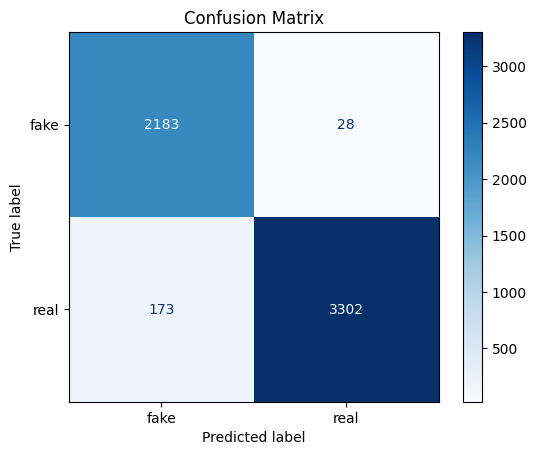


Classification Report:

              precision    recall  f1-score   support

        fake       0.93      0.99      0.96      2211
        real       0.99      0.95      0.97      3475

    accuracy                           0.96      5686
   macro avg       0.96      0.97      0.96      5686
weighted avg       0.97      0.96      0.96      5686



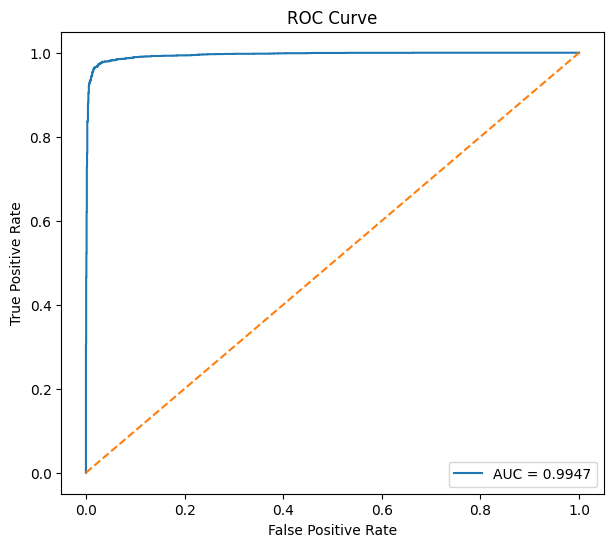


Validation AUC: 0.9947


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive


drive.mount('/content/drive')


model_path = "/content/drive/MyDrive/ArUco/aruco_classifier_model_epoch50.keras"
model = load_model(model_path)

print("Model loaded successfully!")


base_dir = "/content/drive/MyDrive/ArUco/dataset"

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

val_generator = val_datagen.flow_from_directory(
    base_dir,
    target_size=(64, 64),
    batch_size=64,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    seed=42
)

print("Class indices:")
print(val_generator.class_indices)


y_true = val_generator.classes

y_prob = model.predict(val_generator)
y_prob = y_prob.ravel()

# threshold mặc định
threshold = 0.5
y_pred = (y_prob > threshold).astype(int)

# 1. Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["fake", "real"]
)

plt.figure(figsize=(6, 6))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# 2. Classification Report

print("\nClassification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=["fake", "real"]
))

# 3. ROC Curve + AUC

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print(f"\nValidation AUC: {roc_auc:.4f}")